In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import prophet
from statsmodels.tsa.arima.model import ARIMA 
import sklearn

In [1]:
import pandas as pd
import numpy as np

# Gerar datas diárias de 2022-01-01 até 2024-12-31
datas = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')

# Converter para dataframe
df = pd.DataFrame({'data': datas})

# Função para criar padrão sazonal
def gerar_volume(data):
    mes = data.month
    
    # Alta sazonalidade de novembro a fevereiro
    if mes in [11, 12, 1, 2]:
        base = 1000
    # Queda após o pico (março a junho)
    elif mes in [3, 4, 5, 6]:
        base = 600
    # Recuperação gradual (julho a outubro)
    else:  # 7 a 10
        base = 800

    # Adicionar ruído aleatório
    ruido = np.random.normal(0, 80)
    return max(0, base + ruido)

# Aplicar função
df['volume_atendimentos'] = df['data'].apply(gerar_volume).round().astype(int)

# Exportar CSV
df.to_csv('volume_atendimentos.csv', index=False)

print(df.head())
print(f"\nTotal de linhas: {len(df)}")


        data  volume_atendimentos
0 2022-01-01                  964
1 2022-01-02                  929
2 2022-01-03                 1105
3 2022-01-04                  939
4 2022-01-05                  979

Total de linhas: 1096


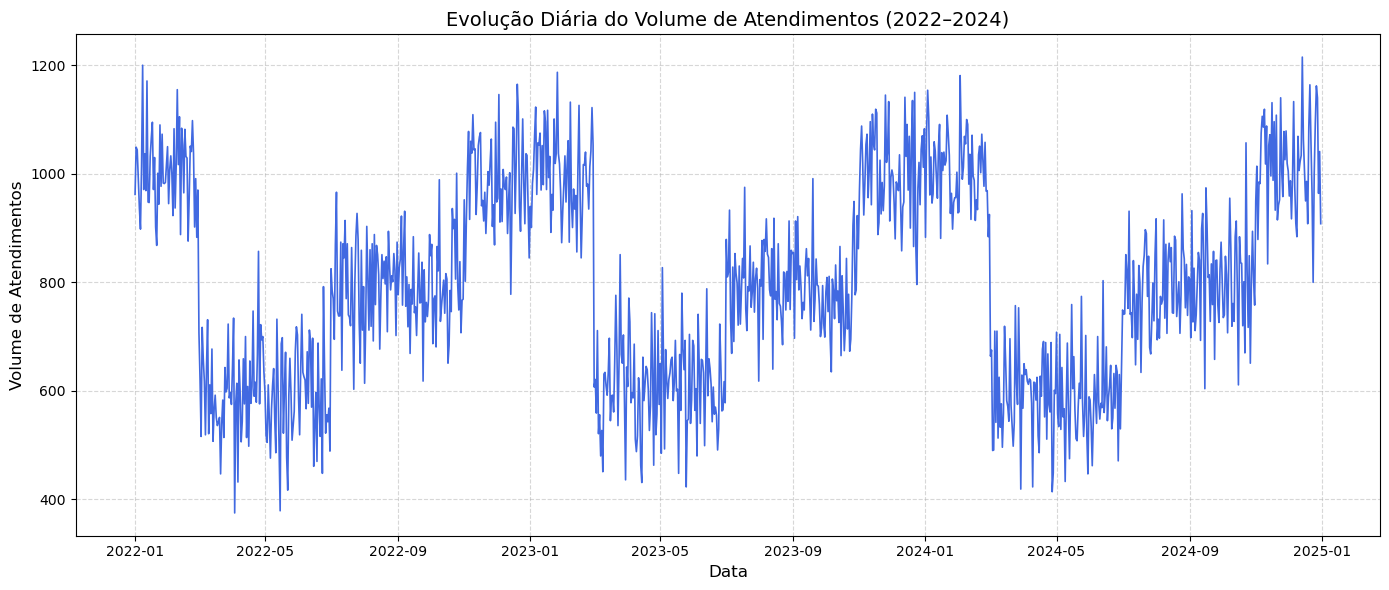

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 1. Gerar dataset =====
datas = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
df = pd.DataFrame({'data': datas})

def gerar_volume(data):
    mes = data.month
    if mes in [11, 12, 1, 2]:
        base = 1000
    elif mes in [3, 4, 5, 6]:
        base = 600
    else:
        base = 800
    ruido = np.random.normal(0, 80)
    return max(0, base + ruido)

df['volume_atendimentos'] = df['data'].apply(gerar_volume).round().astype(int)

# ===== 2. Criar gráfico de linha =====
plt.figure(figsize=(14,6))
sns.lineplot(x='data', y='volume_atendimentos', data=df, linewidth=1.2, color='royalblue')

plt.title('Evolução Diária do Volume de Atendimentos (2022–2024)', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Volume de Atendimentos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


R²: 0.0063
MAE: 153.46
RMSE: 180.56


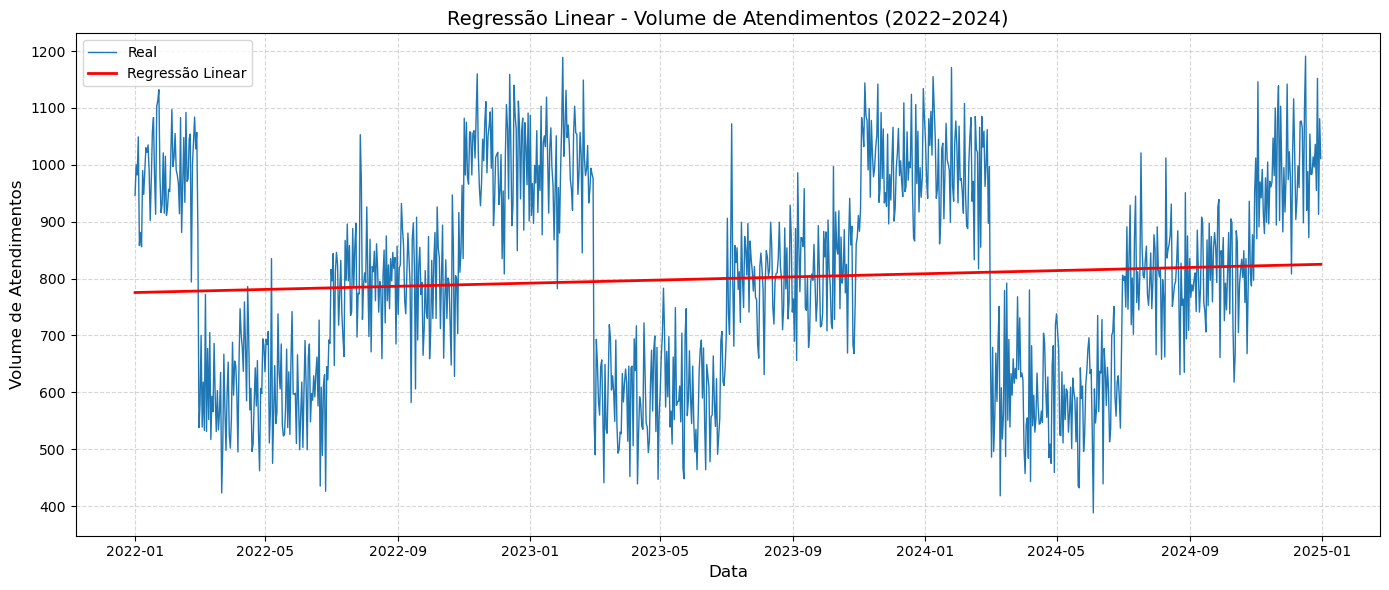

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import prophet
from statsmodels.tsa.arima.model import ARIMA 

# ===== 1. Gerar dataset =====
datas = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
df = pd.DataFrame({'data': datas})

def gerar_volume(data):
    mes = data.month
    if mes in [11, 12, 1, 2]:
        base = 1000
    elif mes in [3, 4, 5, 6]:
        base = 600
    else:
        base = 800
    ruido = np.random.normal(0, 80)
    return max(0, base + ruido)

df['volume_atendimentos'] = df['data'].apply(gerar_volume).round().astype(int)

# ===== 2. Preparar dados para regressão =====
df['dia_num'] = np.arange(len(df))  # transformar data em número crescente

X = df[['dia_num']]
y = df['volume_atendimentos']

# ===== 3. Treinar modelo =====
modelo = LinearRegression()
modelo.fit(X, y)

# Predições
df['predito'] = modelo.predict(X)

# ===== 4. Métricas =====
r2 = r2_score(y, df['predito'])
mae = mean_absolute_error(y, df['predito'])
rmse = mean_squared_error(y, df['predito'], squared=False)

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# ===== 5. Plotar gráfico =====
plt.figure(figsize=(14,6))
sns.lineplot(x='data', y='volume_atendimentos', data=df, label='Real', linewidth=1)
sns.lineplot(x='data', y='predito', data=df, label='Regressão Linear', color='red', linewidth=2)

plt.title('Regressão Linear - Volume de Atendimentos (2022–2024)', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Volume de Atendimentos', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


R²: 0.9328
MAE: 22.03
RMSE: 27.79


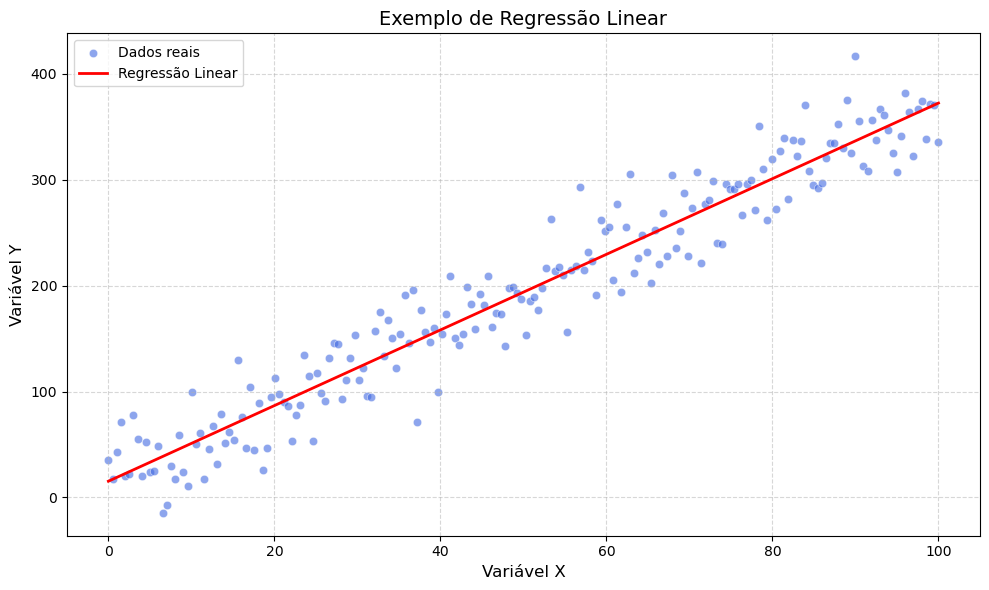

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ===== 1. Gerar dataset linear =====
np.random.seed(42)  # para reprodutibilidade
n = 200  # quantidade de pontos

# Variável independente (x)
x = np.linspace(0, 100, n)

# Relação linear com ruído controlado
y = 3.5 * x + 20 + np.random.normal(0, 30, n)  # ruído moderado

# Criar DataFrame
df = pd.DataFrame({'x': x, 'y': y})

# ===== 2. Ajustar regressão linear =====
X = df[['x']]
y_real = df['y']

modelo = LinearRegression()
modelo.fit(X, y_real)

df['y_predito'] = modelo.predict(X)

# ===== 3. Métricas =====
r2 = r2_score(y_real, df['y_predito'])
mae = mean_absolute_error(y_real, df['y_predito'])
rmse = mean_squared_error(y_real, df['y_predito'], squared=False)

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# ===== 4. Plotar gráfico =====
plt.figure(figsize=(10,6))
sns.scatterplot(x='x', y='y', data=df, color='royalblue', alpha=0.6, label='Dados reais')
sns.lineplot(x='x', y='y_predito', data=df, color='red', linewidth=2, label='Regressão Linear')

plt.title('Exemplo de Regressão Linear', fontsize=14)
plt.xlabel('Variável X', fontsize=12)
plt.ylabel('Variável Y', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# ===== 1. Gerar dataset =====
datas = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
df = pd.DataFrame({'data': datas})

def gerar_volume(data):
    mes = data.month
    if mes in [11, 12, 1, 2]:
        base = 1000
    elif mes in [3, 4, 5, 6]:
        base = 600
    else:
        base = 800
    ruido = np.random.normal(0, 80)
    return max(0, base + ruido)

df['volume_atendimentos'] = df['data'].apply(gerar_volume).round().astype(int)

# Prophet exige colunas específicas: ds (data) e y (valor)
df_prophet = df.rename(columns={'data': 'ds', 'volume_atendimentos': 'y'})

# ===== 2. Treinar modelo Prophet =====
modelo = Prophet(
    yearly_seasonality=True,
    daily_seasonality=False,
    weekly_seasonality=False,
    stan_backend='CMDSTANPY'
)
modelo.fit(df_prophet)

# ===== 3. Fazer previsão =====
futuro = modelo.make_future_dataframe(periods=365)  # prever 1 ano à frente
forecast = modelo.predict(futuro)

# ===== 4. Plotar previsão =====
modelo.plot(forecast, figsize=(12,6))
plt.title('Previsão de Volume de Atendimentos - Prophet', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Volume de Atendimentos')
plt.tight_layout()
plt.show()

# ===== 5. Decomposição: tendência, sazonalidade, ciclo =====
modelo.plot_components(forecast)
plt.suptitle('Componentes da Série Temporal (Tendência, Sazonalidade, Ciclo)', fontsize=14)
plt.tight_layout()
plt.show()


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x80 in position 7: invalid start byte

In [24]:
pip install neuralprophet pandas matplotlib seaborn

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 14.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ----- ---------------------------------- 2.4/15.8 MB 15.0 MB/s eta 0:00:01
   ---------------- ----------------------- 6.6/15.8 MB 16.8 MB/s eta 0:00:01
   --------------------------- ------------ 11.0/15.8 MB 17.6 MB/s eta 0:00:01
   ------------------------------------- -- 14.9/15.8 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 16.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------------ --------------------- 4.5/9.9 MB 20.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/9.9 MB 19.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 18.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/831.6 kB ? eta -:--:--
   -----------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# neuralprophet_example.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet

# --- Gerar dataset (mesmo padrão de antes) ---
datas = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
df = pd.DataFrame({'ds': datas})

def gerar_volume(data):
    mes = data.month
    if mes in [11, 12, 1, 2]:
        base = 1000
    elif mes in [3, 4, 5, 6]:
        base = 600
    else:
        base = 800
    ruido = np.random.normal(0, 80)
    return max(0, base + ruido)

df['y'] = df['ds'].apply(gerar_volume).round().astype(int)

# --- Ajustar NeuralProphet ---
m = NeuralProphet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_forecasts=0,    # queremos apenas a previsão ponto-a-ponto no futuro via make_future_dataframe
)

# treinar (epochs baixo para ser rápido; aumente se quiser)
metrics = m.fit(df, freq='D', epochs=100, verbose=False)

# criar futuro (1 ano adiante) e prever
future = m.make_future_dataframe(df, periods=365)
forecast = m.predict(future)

# --- Plots ---
# 1) Série e previsão
fig1 = m.plot(forecast)
fig1.suptitle('Forecast - NeuralProphet', fontsize=14)

# 2) Componentes (trend + yearly seasonality)
fig2 = m.plot_components(forecast)
fig2.suptitle('Componentes - Tendência e Sazonalidade (NeuralProphet)', fontsize=14)

plt.show()

# opcional: exportar
df_forecast = forecast[['ds', 'yhat1']].rename(columns={'yhat1':'yhat'})
df_forecast.to_csv('forecast_neuralprophet.csv', index=False)
print("CSV salvo: forecast_neuralprophet.csv")


ImportError: cannot import name 'TypeIs' from 'typing_extensions' (c:\Users\LEONARDO\anaconda3\Lib\site-packages\typing_extensions.py)